In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import PlotStyler
from pynamicalsys import ContinuousDynamicalSystem as cds
from pynamicalsys import HamiltonianSystem as HS

In [2]:
time_step = 0.01

In [3]:
E = 1 / 8  # Total energy of the system
x = 0  # Define the initial condition
y = 0.1
py = 0
px = np.sqrt(2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2)

dof = 2
q = np.array([x, y])
p = np.array([px, py])

u = np.array([x, y, px, py])

total_time = 10000

In [19]:
ds = cds(model="henon heiles")
ds.integrator("rk4", time_step=time_step)

In [21]:
%%time
trajectory = ds.trajectory(u, total_time)

CPU times: user 336 ms, sys: 7.8 ms, total: 344 ms
Wall time: 344 ms


In [22]:
hs = HS(model="henon heiles")
hs.integrator("svy4", time_step=time_step)

In [23]:
%%time
symp_trajectory = hs.trajectory(q, p, total_time)

CPU times: user 515 ms, sys: 6.91 ms, total: 522 ms
Wall time: 528 ms


In [8]:
symp_trajectory.shape

(1000001, 5)

In [24]:
hs.integrator("vv2", time_step=time_step)

In [25]:
%%time
symp_trajectory_vv2 = hs.trajectory(q, p, total_time)

CPU times: user 179 ms, sys: 1.67 ms, total: 181 ms
Wall time: 182 ms


In [26]:
hs.integrator("imp", time_step=time_step)

In [28]:
%%time
symp_trajectory_imp = hs.trajectory(q, p, total_time)

CPU times: user 2.41 s, sys: 15.1 ms, total: 2.43 s
Wall time: 2.43 s


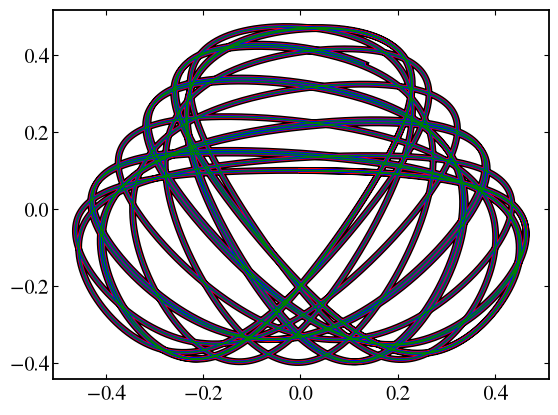

In [13]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

num_plot = 10000
plt.plot(trajectory[:num_plot, 1], trajectory[:num_plot, 2], "k", lw=5)
plt.plot(symp_trajectory[:num_plot, 1], symp_trajectory[:num_plot, 2], "r", lw=3)

plt.plot(symp_trajectory_vv2[:num_plot, 1], symp_trajectory_vv2[:num_plot, 2], "b", lw=2)

plt.plot(symp_trajectory_imp[:num_plot, 1], symp_trajectory_imp[:num_plot, 2], "g", lw=1)

In [14]:
def total_energy(q, p):
    V = 0.5 * (q[0] * q[0] + q[1] * q[1]) + q[0] * q[0] * q[1] - q[1] * q[1] * q[1] / 3.0
    T = 0.5 * (p[0] ** 2 + p[1] ** 2)

    return T + V

In [17]:
Et = np.zeros((symp_trajectory.shape[0] - 1, 5))
for i in range(Et.shape[0]):
    Et[i, 0] = symp_trajectory[i + 1, 0]

    q = trajectory[i, 1: dof + 1]
    p = trajectory[i, dof + 1:]
    Et[i, 1] = total_energy(q, p)

    q = symp_trajectory[i + 1, 1: dof + 1]
    p = symp_trajectory[i + 1, dof + 1:]
    Et[i, 2] = total_energy(q, p)

    q = symp_trajectory_vv2[i + 1, 1: dof + 1]
    p = symp_trajectory_vv2[i + 1, dof + 1:]
    Et[i, 3] = total_energy(q, p)

    q = symp_trajectory_imp[i + 1, 1: dof + 1]
    p = symp_trajectory_imp[i + 1, dof + 1:]
    Et[i, 4] = total_energy(q, p)

Text(0, 0.5, 'Relative energy error')

<Figure size 640x480 with 0 Axes>

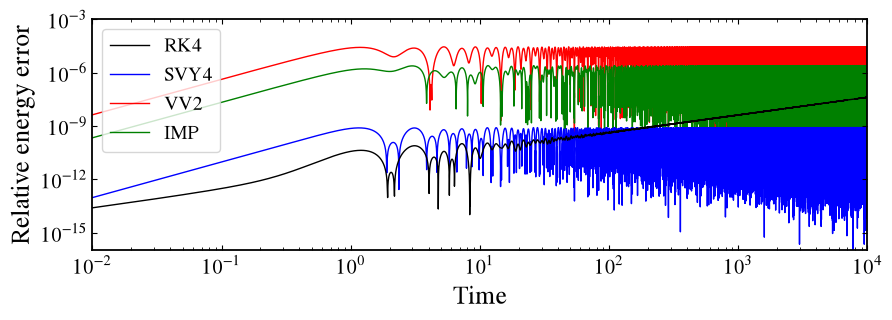

In [18]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

fig, ax = plt.subplots(figsize=(10, 3))
plt.plot(Et[:, 0], abs(Et[:, 1] - E)/E, "k", label="RK4", zorder=2)
plt.plot(Et[:, 0], abs(Et[:, 2] - E)/E, "b", label="SVY4", zorder=1)
plt.plot(Et[:, 0], abs(Et[:, 3] - E)/E, "r", label="VV2", zorder=0)
plt.plot(Et[:, 0], abs(Et[:, 4] - E)/E, "g", label="IMP", zorder=0)

plt.legend(loc="upper left")
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-16, 1e-3)
plt.xlim(time_step, total_time)
plt.xlabel("Time")
plt.ylabel("Relative energy error")